# Tech Challenge Fase 3 — Notebook 05: regressão lag-1

Os notebooks 03–04 classificam a meta **sem** a taxa do próprio ano e empatam com cara ou coroa. Aqui a pergunta muda:

**Com a taxa de 2023 (já observada), qual é a taxa de 2024?** Depois: essa taxa *prevista* bate a meta de 2024?

Persistência (`taxa_2024 ≈ taxa_2023`) é o Dummy desta etapa. OLS em cima do lag é o palpite. Nada disto usa 2024 para treinar coeficientes — o ajuste é descritivo no painel emparelhado; a métrica honesta é MAE/R² no próprio 2024 (não há 2025 neste Silver).


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.modeling.lag1 import (
    classification_from_predicted_rate,
    fit_lag1_ols,
    pair_consecutive_years,
    regression_metrics,
)
from src.preprocessing.silver_schema import load_silver_table

df, silver_path = load_silver_table(ROOT / 'data' / 'silver')
print('Silver:', silver_path)
print(df.shape)
Path('../reports/figures').mkdir(parents=True, exist_ok=True)

Silver: /Users/vinicius/Documents/workspace/tech_challenge_fase3/data/silver/indicador_alfabetizacao
(10896, 46)


/Users/vinicius/Documents/workspace/tech_challenge_fase3/src/preprocessing/silver_schema.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return normalize_silver_frame(pd.concat(frames, ignore_index=True))


## 1. Emparelhar o mesmo município em 2023 e 2024

Uma linha = um município que existe nos dois anos. `taxa_lag` é 2023; `taxa_alvo` é 2024.


In [2]:
paired = pair_consecutive_years(df)
print(f'Municípios emparelhados: {len(paired):,}')
print(paired[['id_municipio', 'taxa_lag', 'taxa_alvo', 'meta_2024']].head())
print('\nCorrelação taxa_2023 vs taxa_2024:',
      paired['taxa_lag'].corr(paired['taxa_alvo']))

Municípios emparelhados: 5,396
  id_municipio  taxa_lag  taxa_alvo  meta_2024
0      2901700     33.89      25.76      40.74
1      2903276     42.08      46.15      48.11
2      2908200     31.68      27.46      38.68
3      2910206     85.87      52.38      80.00
4      2910727     34.62      38.37      41.41

Correlação taxa_2023 vs taxa_2024: 0.6358177708449055


## 2. Três palpites de regressão

- **Média:** todo mundo recebe a média de 2024 (chão ingênuo).
- **Persistência:** copiar 2023 (o Dummy temporal).
- **OLS:** reta `taxa_2024 = a + b · taxa_2023`.


                        MAE    RMSE     R2   corr
modelo                                           
Média                16.073  19.306  0.000 -0.000
Persistência (2023)  12.514  16.893  0.234  0.636
OLS lag-1            11.693  14.901  0.404  0.636

OLS: intercepto=25.496  coeficiente=0.621


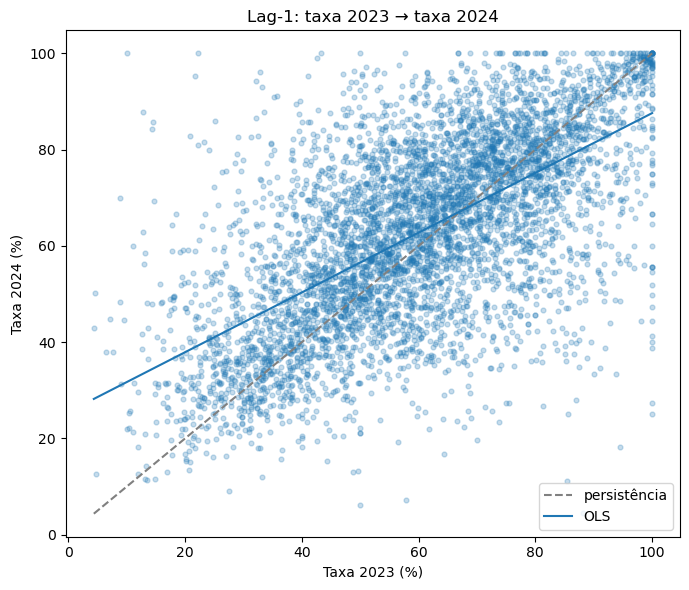

In [3]:
y = paired['taxa_alvo']
persist = paired['taxa_lag']
mean_pred = pd.Series(y.mean(), index=paired.index)
ols = fit_lag1_ols(paired['taxa_lag'], y)
ols_pred = pd.Series(ols.predict(paired[['taxa_lag']]), index=paired.index)

rows = []
for name, pred in [('Média', mean_pred), ('Persistência (2023)', persist), ('OLS lag-1', ols_pred)]:
    m = regression_metrics(y, pred)
    m['modelo'] = name
    rows.append(m)
reg_table = pd.DataFrame(rows).set_index('modelo')[['MAE', 'RMSE', 'R2', 'corr']]
print(reg_table.round(3))
print(f'\nOLS: intercepto={ols.intercept_:.3f}  coeficiente={ols.coef_[0]:.3f}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(paired['taxa_lag'], y, alpha=0.25, s=12)
grid = np.linspace(paired['taxa_lag'].min(), paired['taxa_lag'].max(), 50)
ax.plot(grid, grid, '--', color='gray', label='persistência')
ax.plot(grid, ols.predict(pd.DataFrame({'taxa_lag': grid})), color='C0', label='OLS')
ax.set_xlabel('Taxa 2023 (%)')
ax.set_ylabel('Taxa 2024 (%)')
ax.set_title('Lag-1: taxa 2023 → taxa 2024')
ax.legend()
fig.tight_layout()
fig.savefig('../reports/figures/lag1_scatter.png', dpi=120)
plt.show()

## 3. Da taxa prevista para “na meta”

A meta municipal de 2024 já era pública. Classificar `taxa prevista >= meta` é o uso político do palpite, sem colar a taxa realizada de 2024 no X.


In [4]:
clf_rows = []
for name, pred in [('Persistência', persist), ('OLS lag-1', ols_pred)]:
    clf = classification_from_predicted_rate(y, pred, paired['meta_2024'])
    clf['modelo'] = name
    clf_rows.append(clf)
clf_table = pd.DataFrame(clf_rows).set_index('modelo')
print(clf_table.round(3))
print('\nLembrete notebooks 03–04: logística contemporânea F1 ≈ 0,45, acerto equilibrado ≈ 0,51.')

y_true_cls = (y >= paired['meta_2024']).astype(int)
print('Prevalência na meta em 2024:', float(y_true_cls.mean()))

                 F1  balanced_acc  Dummy_sempre_1_F1  \
modelo                                                 
Persistência  0.275         0.512              0.681   
OLS lag-1     0.566         0.558              0.681   

              Dummy_sempre_1_balanced_acc  
modelo                                     
Persistência                          0.5  
OLS lag-1                             0.5  

Lembrete notebooks 03–04: logística contemporânea F1 ≈ 0,45, acerto equilibrado ≈ 0,51.
Prevalência na meta em 2024: 0.5166790214974055


## 4. Como ler

- Se persistência ganhar do OLS, a reta não acrescenta quase nada além de “ano que vem parece ano passado”.
- Se MAE da persistência for da ordem de 6–8 pontos, o gestor ainda erra a taxa — mas isso é **informação**, não cola.
- A classificação via taxa prevista deve ser comparada ao Dummy “sempre 1” e à logística do notebook 04, não celebrada isolada.
- Não há 2025 neste arquivo: não há holdout futuro depois de 2024. O R² aqui é descritivo no mesmo par de anos.
